# VLA C-band beam validation

This notebook is the executable scientific account of the THOL0001 SPW-4 CASSBEAM comparison. It starts from the compact, checksummed validation bundle. It does not read the Measurement Set, invoke CASA, or freeze a production beam.

Full-Jones panels are experimental. SPW 5 is sealed.

In [1]:
from pathlib import Path

from sl1mjax.beam_validation_outputs import default_bundle_root, load_bundle
from sl1mjax.beam_validation_plots import write_all_figures
from sl1mjax.beam_validation_statistics import (
    claim_table,
    copolar_correlation,
    copolar_slope,
    crosshand_non_detection,
    frequency_copolar_series,
    offset_ring_diagonal_closure,
    publication_squint_pair,
    residual_power_table,
)

bundle = load_bundle()
figure_dir = Path("docs/assets/vla_c_band_beam_validation")
written = write_all_figures(bundle, figure_dir)
print(bundle.root)
print("publication", bundle.manifest["publication_version"])
print("bundle_sha256", bundle.manifest["bundle_sha256"])
print("schema", bundle.manifest["schema_version"])
print("wrote", len(written), "figure files")


/Users/stephen/checkouts/SL1MJax/src/sl1mjax/data/vla_c_band_beam_validation_v1
publication vla_c_band_beam_validation_v1
bundle_sha256 1048a28070ae96a8a2b2d233d9e4479b3e52c9bcdebe424229fc81a85188f775
schema 3
wrote 41 figure files


## 1. Executive summary

CASSBEAM is the reference diagonal C-band beam inside a stated validity domain. The claim registry below is loaded from the bundle. The notebook does not invent claim status.

In [2]:
rows = claim_table(bundle)
print(f"{'id':<4} {'status':<10} {'class':<28} title")
for row in rows:
    print(f"{row['id']:<4} {row['status']:<10} {str(row.get('support_class','')):<28} {row['title']}")


id   status     class                        title
C01  pass       accepted                     CASSBEAM is the SPW-4 diagonal C-band reference in the main lobe
C02  warn       qualified                    Middle-beam CASSBEAM is useful but imperfect
C03  warn       diagnostic                   Outer-raster CASSBEAM is diagnostic only
C04  pass       accepted                     The C147-* offset ring independently supports the diagonal beam
C05  blocked    experimental_non_detection   CASSBEAM full Jones is an experimental non-detection
C06  not_run    frequency_transfer           SPW 5 remains sealed
C07  pass       squint                       Publication squint uses the 20%-of-peak main-lobe estimator


In [3]:
residuals = residual_power_table(bundle.holoraster_channel32)
print("Quoted % residual power is not a flux error.")
print("region            RR power   RR RMS vis   RR med|dV|/I   LL power   LL RMS vis   LL med|dV|/I")
for name in ("main_lobe", "mid", "outer_diagnostic", "all"):
    row = residuals[name]
    print(
        f"{name:<17} {100*row['rr']:7.2f}%  {100*row['rr_rms']:9.2f}%  "
        f"{100*row['rr_median_abs_over_i']:11.2f}%  "
        f"{100*row['ll']:7.2f}%  {100*row['ll_rms']:9.2f}%  "
        f"{100*row['ll_median_abs_over_i']:11.2f}%"
    )
print("RR slope", copolar_slope(bundle.holoraster_channel32, "rr"))
print("LL slope", copolar_slope(bundle.holoraster_channel32, "ll"))
print("RR corr", copolar_correlation(bundle.holoraster_channel32, "rr"))
print("LL corr", copolar_correlation(bundle.holoraster_channel32, "ll"))
print("n_rows", bundle.holoraster_channel32["n_rows"])
print("frequency_hz", bundle.holoraster_channel32["frequency_hz"])
print("source I_model Jy", bundle.residual_strata.get("source_i_jy"))


Quoted % residual power is not a flux error.
region            RR power   RR RMS vis   RR med|dV|/I   LL power   LL RMS vis   LL med|dV|/I
main_lobe            0.64%       7.97%         4.83%     0.76%       8.72%         5.04%
mid                  7.70%      27.75%         6.68%     8.91%      29.86%         7.69%
outer_diagnostic    32.31%      56.85%         3.54%    34.85%      59.04%         3.57%
all                  5.74%      23.96%         3.77%     6.34%      25.18%         3.81%
RR slope (1.032376414300634+0.0031632558798339967j)
LL slope (1.0290913957524932+0.0037827236330902005j)
RR corr 0.9713541202861148
LL corr 0.9681786216950763
n_rows 747058
frequency_hz 4564000000.0
source I_model Jy 8.028518676757812


## 2. Why a measured voltage beam is needed

An incomplete beam can appear as spatial, spectral, polarised, or temporal sky structure. The compact-source holography equation is

$$
V_{mr}=E_m(s,\nu,\chi)\,S(\nu)\,E_r(0,\nu,\chi)^{\mathrm H}.
$$

CASSBEAM is a physical model. Holography decides whether a smooth correction is justified. The intended model is $E_{\mathrm{VLA}}=E_{\mathrm{CASSBEAM}}+\Delta E_{\mathrm{holography}}$, with $\Delta E$ introduced only when it improves held-out visibilities.

## 3. THOL0001 observation

`POINTING_OFFSET` is an AZELGEO antenna coordinate. `ON_SOURCE` is not a valid selection field. Version 1 publishes 4.564 GHz only.

In [4]:
obs = bundle.observation
print(obs["project"], "SB", obs["scheduling_block"], "EB", obs["execution_block"])
print("version-1 frequency_hz", obs["version1_frequency_hz"])
print("SPW 5", obs["spw5_status"], obs["spw5_frequency_hz"])
print("POINTING_OFFSET frame", obs["pointing_offset_frame"])
print("ON_SOURCE is a selection field", obs["on_source_is_selection"])
print("references", obs["reference_antenna_names"])
print("occupancy", obs["occupancy"])


THOL0001 SB sb31628704 EB eb31629959
version-1 frequency_hz 4564000000.0
SPW 5 sealed 4692000000.0
POINTING_OFFSET frame AZELGEO
ON_SOURCE is a selection field False
references ['ea02', 'ea03', 'ea07', 'ea12', 'ea14', 'ea24', 'ea26']
occupancy {'n_clustered_cells': 797, 'n_dense_family': 191, 'n_sparse_family': 606, 'pass1_cells': 275, 'pass2_cells': 529}


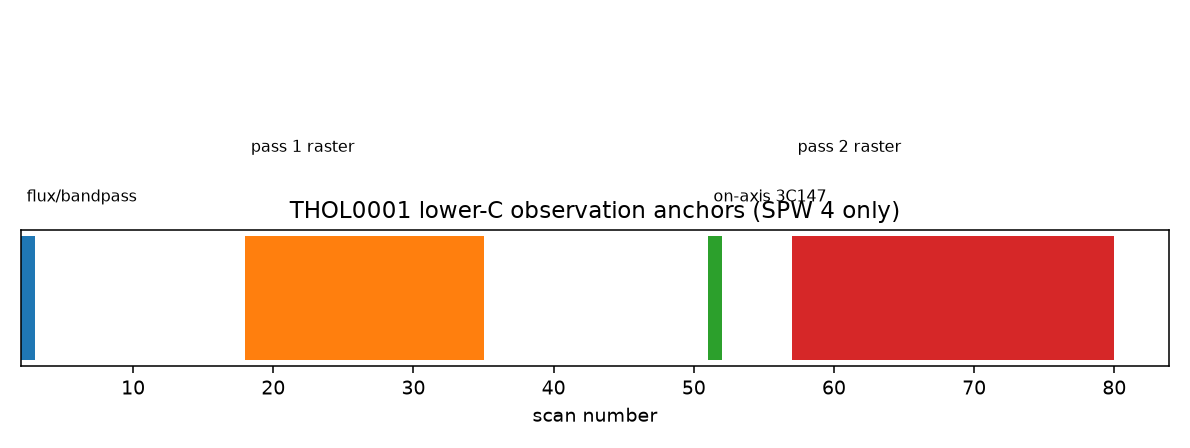

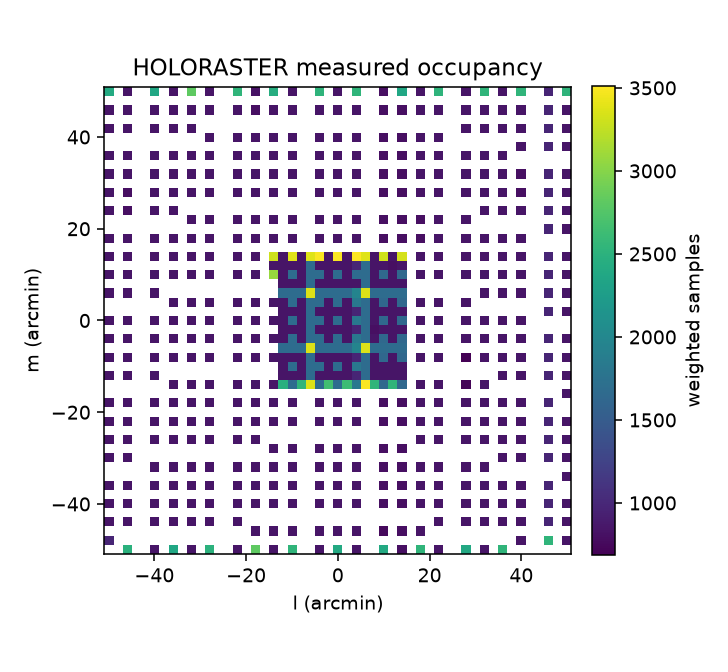

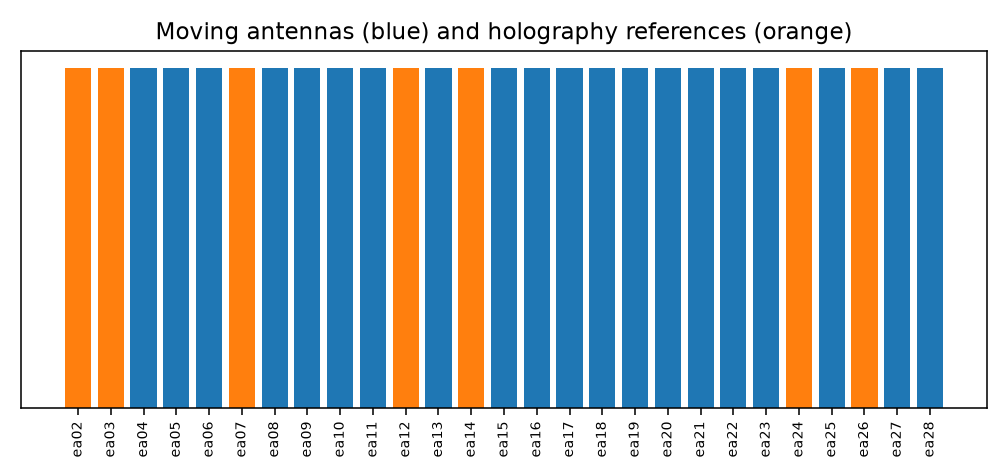

In [5]:
from IPython.display import Image, display

def show(*names):
    root = Path("docs/assets/vla_c_band_beam_validation")
    for name in names:
        display(Image(filename=str(root / name)))

show("01_observation_timeline.png", "02_raster_occupancy.png", "03_antenna_roles.png")


## 4. Calibration and source model

HOLORASTER field 10 already has `CORRECTED_DATA`. C147-* fields 1–8 were never applied on disk; those predictions start from `DATA`. Full-pol uses `parang=True`. The C147-* ring is unused prediction data.

In [6]:
cal = bundle.calibration
print("refant", cal["reference_antenna"], "calwt", cal["calwt"])
print("diagonal parang", cal["diagonal_parang"], "fullpol parang", cal["fullpol_parang"])
print("HOLORASTER apply from", cal["apply_holoraster_from"])
print("C147-* apply from", cal["apply_c147_offset_from"])
print("source model", cal["source_model"])
print("3C286", cal["three_c286"])


refant ea02 calwt False
diagonal parang False fullpol parang True
HOLORASTER apply from CORRECTED_DATA
C147-* apply from DATA
source model {'name': '3C147', 'kind': 'point', 'standard': 'Perley-Butler 2017'}
3C286 {'casaguide_two_chi_deg': 66.0, 'iau_evpa_deg': 33.0, 'residual_x_deg': -0.3824005126953125, 'v_over_i': -0.004271958488970995}


## 5. Convention and software correctness

These residuals lock CASA/JAX apply semantics. They are not evidence that CASSBEAM is physically correct. The 128-member convention search is closed.

In [7]:
gates = bundle.convention_gates
print("software gates passed", gates["software_gates_passed"])
print("convention", gates["cassbeam_convention"])
print("not physical beam evidence", gates["not_physical_beam_evidence"])
for name, row in (gates.get("cumulative_residuals") or {}).items():
    print(name, row.get("median_rel_l2"))


software gates passed True
convention {'l_sign': 1, 'm_sign': 1, 'swap_lm': False, 'jones': 'native', 'swap_rl': False, 'rotate_spatial': False, 'note': 'Locked mount-frame native packing. The 128-convention search is not reopened.'}
not physical beam evidence True
K+B+G 0.002857593215032758
K+B+G+Kcross 0.01640301260117932
K+B+G+Kcross+Df 0.02226890583604062
K+B+G+Kcross+Df+Xf 0.022268922893577053
K+B+G+Kcross+Df+Xf+P 0.01634986503966375


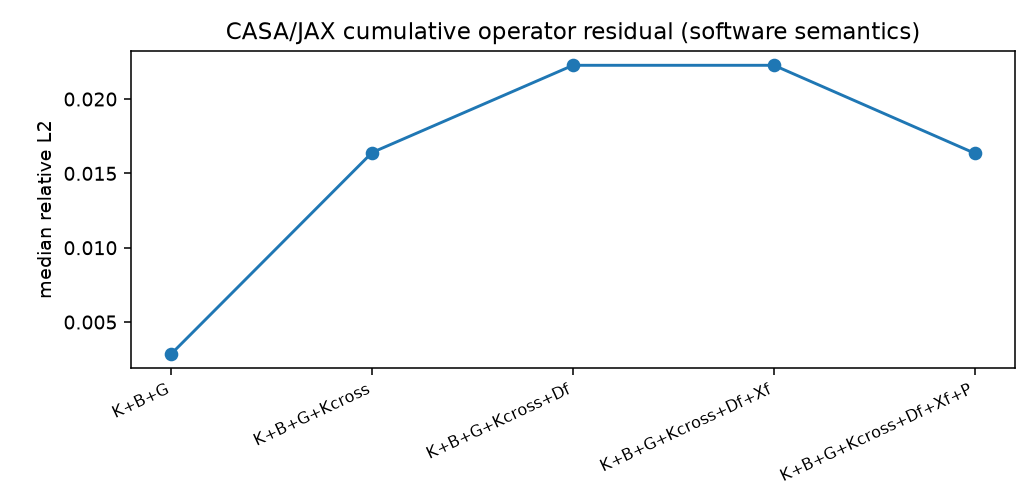

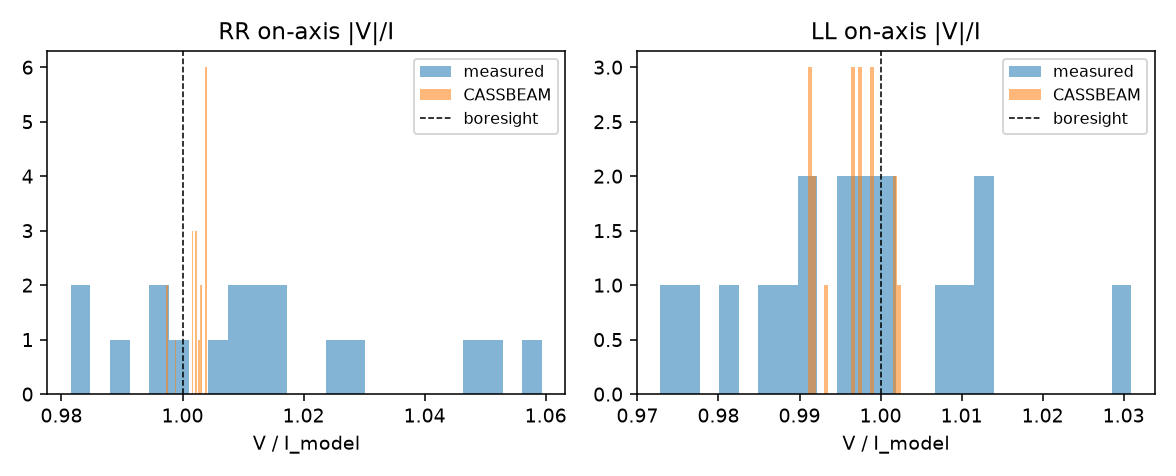

In [8]:
show("04_casa_jax_operator_residual.png", "05_onaxis_amplitude.png")


## 6–8. Direct HOLORASTER comparison

Every calibrated moving–reference visibility is compared with CASSBEAM at the measured AZELGEO coordinate. No coefficient is fitted. The source is at the phase centre, so the geometric fringe is identically one.

On axis, $V_{mr}\simeq S$ with $E_m(0)=E_r(0)=1$. Flux calibration cannot remove an off-axis beam error without spoiling that on-axis agreement. Away from the origin, $\Delta V(s)\simeq S\,[E_{\mathrm{measured}}(s)-E_{\mathrm{CASSBEAM}}(s)]$. A 1 Jy residual on this 8 Jy calibrator is a voltage-beam error of about 0.125, not a missing flux-scale factor.

The quoted residual-power scores are not flux or amplitude errors. Their square roots are the RMS visibility errors. The notebook also reports median $|\Delta V|/I$. The publication scatter uses the same $V/I_{\mathrm{model}}$ main-lobe mask as the claimed metric.

Maps are visibility-domain binned means, not recovered $E$ interpolants. Unsupported cells are masked. Raster-family residuals are a Memo 195 dense/sparse occupancy proxy, not a scan-id join.

The measured raster reaches about $\pm 51'$ and $71'$ in the corners. High-resolution CASSBEAM covers essentially that whole field. Outer-beam CASSBEAM captures substantial coherent structure (complex correlation about 0.82), but residual power of 32--35% and a median amplitude ratio near 1.6 mean it is not yet an unqualified bright-source predictor. The first-null region near 20--30′ is poorly predicted; coherence partially returns in the next sidelobe. F24 shows the same radial degradation across the 20 movers.

The dB ratio is a diagnostic, not a multiplicative correction. When CASSBEAM predicts only 0.05--0.15 Jy and the residual floor is about 0.2 Jy, magnitude ratios are biased upward. A correction would need coherent complex averaging, uncertainty propagation, and transfer across held-out antennas and cells. Phase means are exploratory and must not be read as a general outer phase correction.

For a common scalar beam, $E_p(s)E_q(s)^{*}=|E(s)|^{2}$, so a shared voltage phase—and even a shared $\pi$ lobe sign—cancels in ordinary Stokes I. Outer-lobe magnitude is the main imaging concern. Phase matters when antenna beams differ, for R/L differences and cross-polar terms, and for antenna-dependent Jones beams.

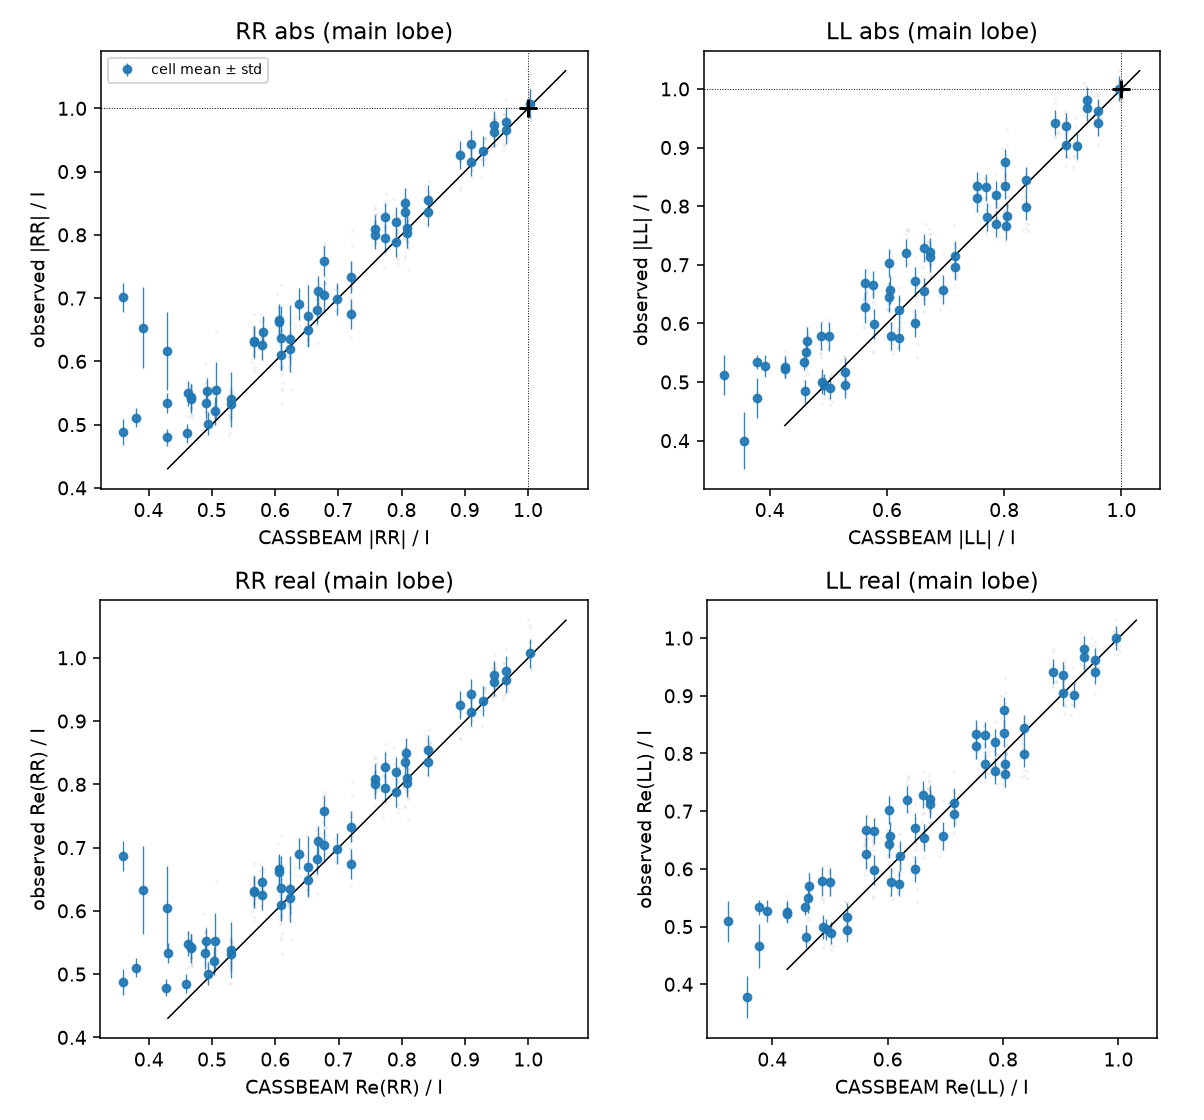

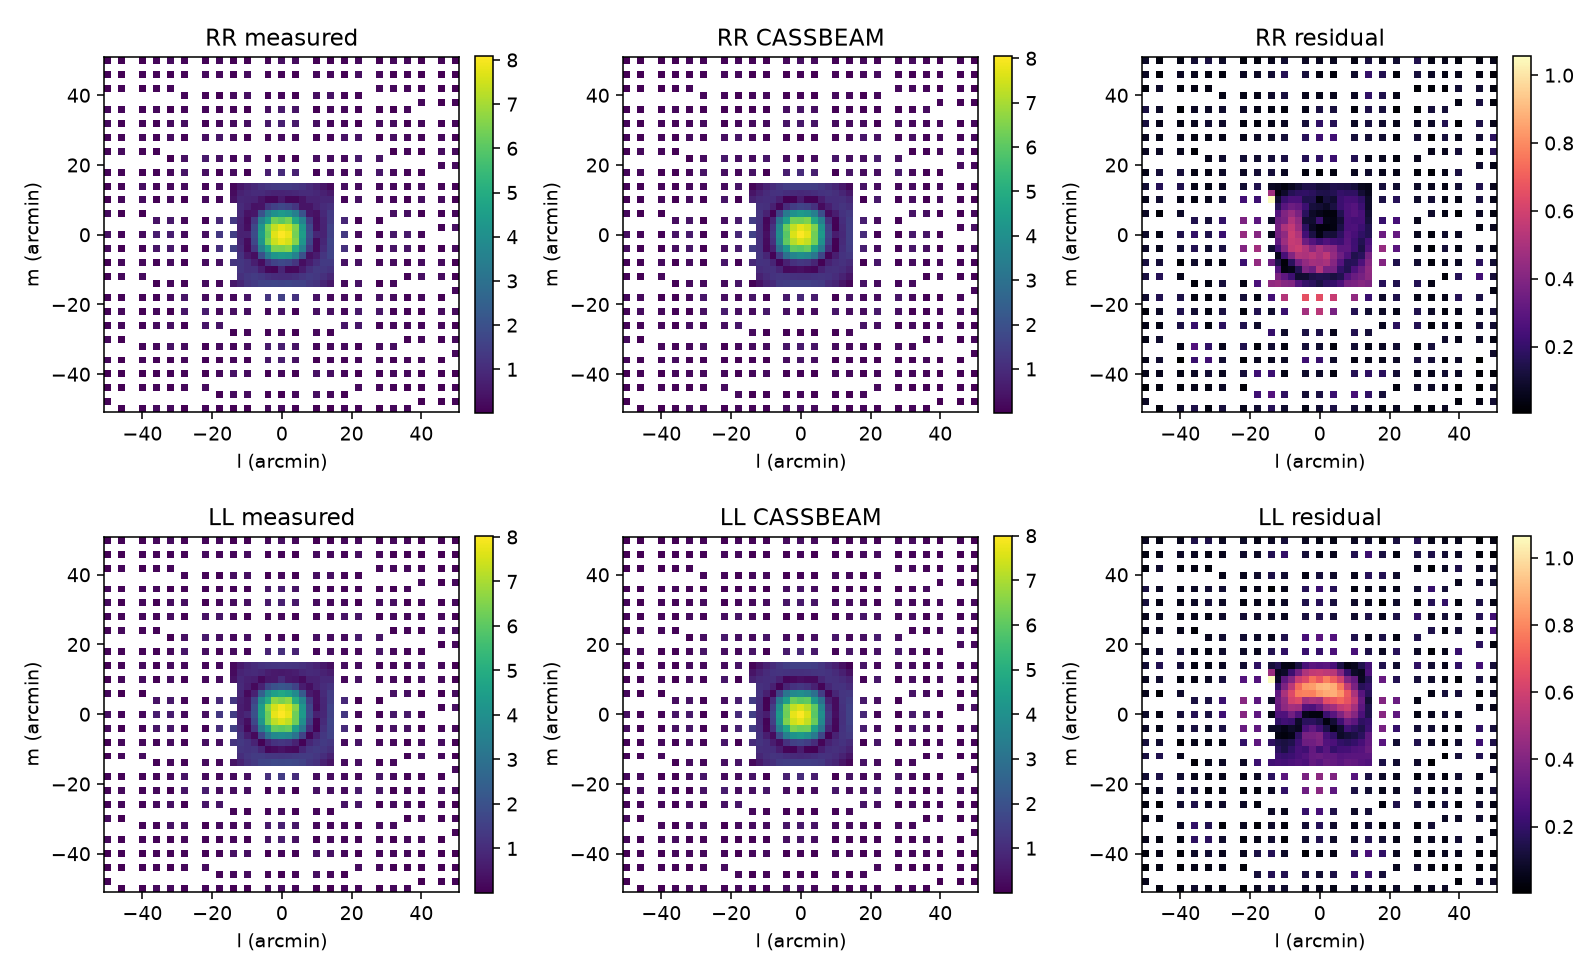

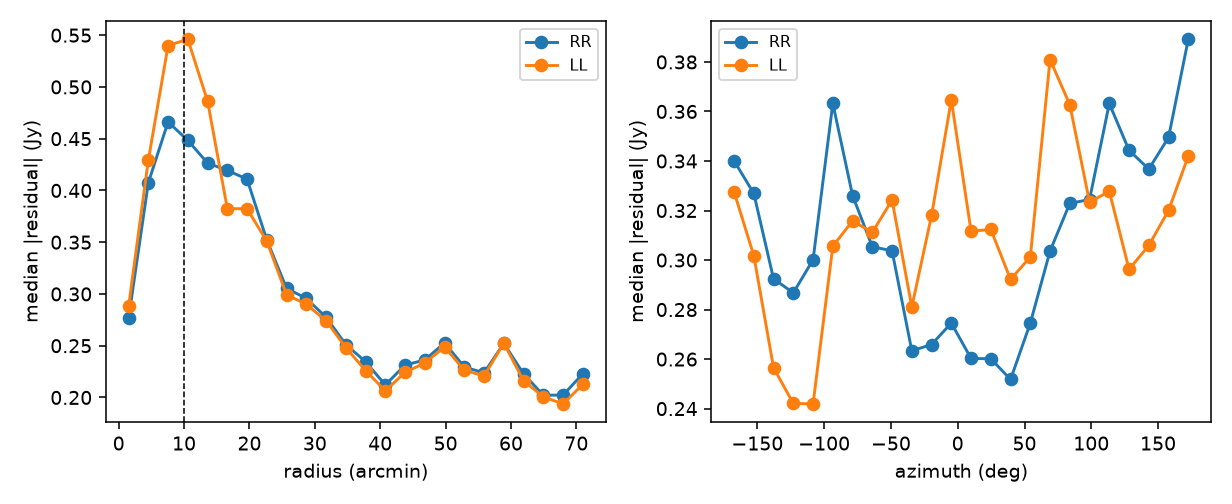

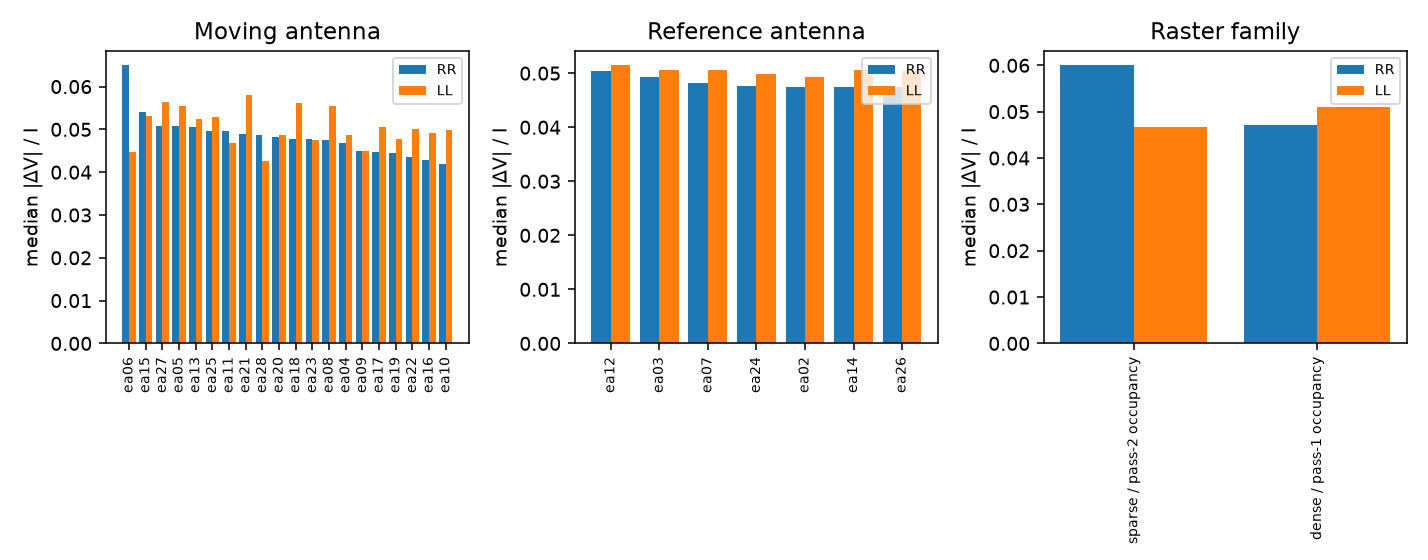

mask V/I_model using CASA MODEL_DATA 3C147 at channel 32
raster_family Nearest Memo 195 dense versus sparse lattice. This is a pass-1/pass-2 occupancy proxy, not a scan-id join.
mover [('ea06', 2144, 0.5225706904878613), ('ea15', 2203, 0.43492696659793345), ('ea27', 2169, 0.40720462342038083), ('ea05', 2181, 0.406858081211476), ('ea13', 2141, 0.405116485319654), ('ea25', 2145, 0.39923929130213326), ('ea11', 2151, 0.3980985206820187), ('ea21', 2213, 0.39191130167003446)]
reference [('ea12', 6205, 0.4047977611834499), ('ea03', 6195, 0.39502386058860695), ('ea07', 6170, 0.38631174232527266), ('ea24', 6200, 0.3826905228912197), ('ea02', 6203, 0.38161300273049376), ('ea14', 6191, 0.3807498352265524), ('ea26', 6211, 0.3803441024412791)]
pass [('sparse / pass-2 occupancy', 4438, 0.482616805479728), ('dense / pass-1 occupancy', 38937, 0.37851565696641104)]


In [9]:
show(
    "08_cassbeam_scatter_main_lobe.png",
    "10_spatial_measured_cassbeam_residual.png",
    "12_residual_vs_radius.png",
    "15_residual_strata.png",
)
strata = bundle.residual_strata
print("mask", strata.get("mask"))
print("raster_family", strata.get("raster_family"))
for key in ("mover", "reference", "pass"):
    print(key, [(row.get("name"), row.get("n"), row.get("median_abs")) for row in strata.get(key) or ()][:8])


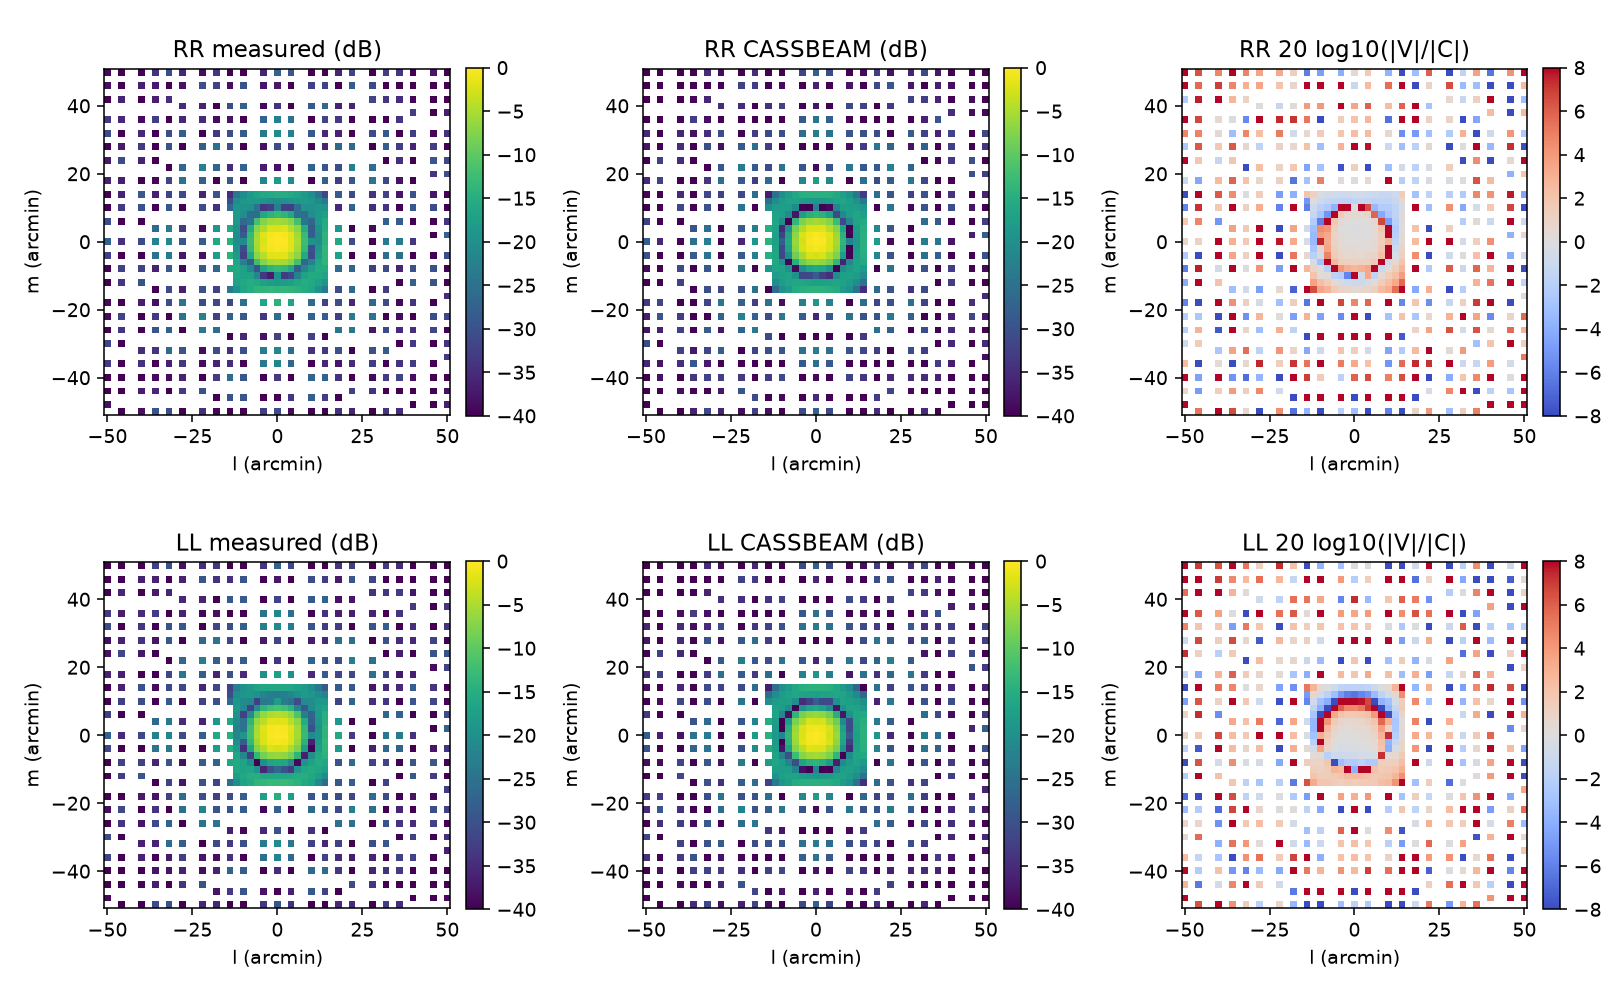

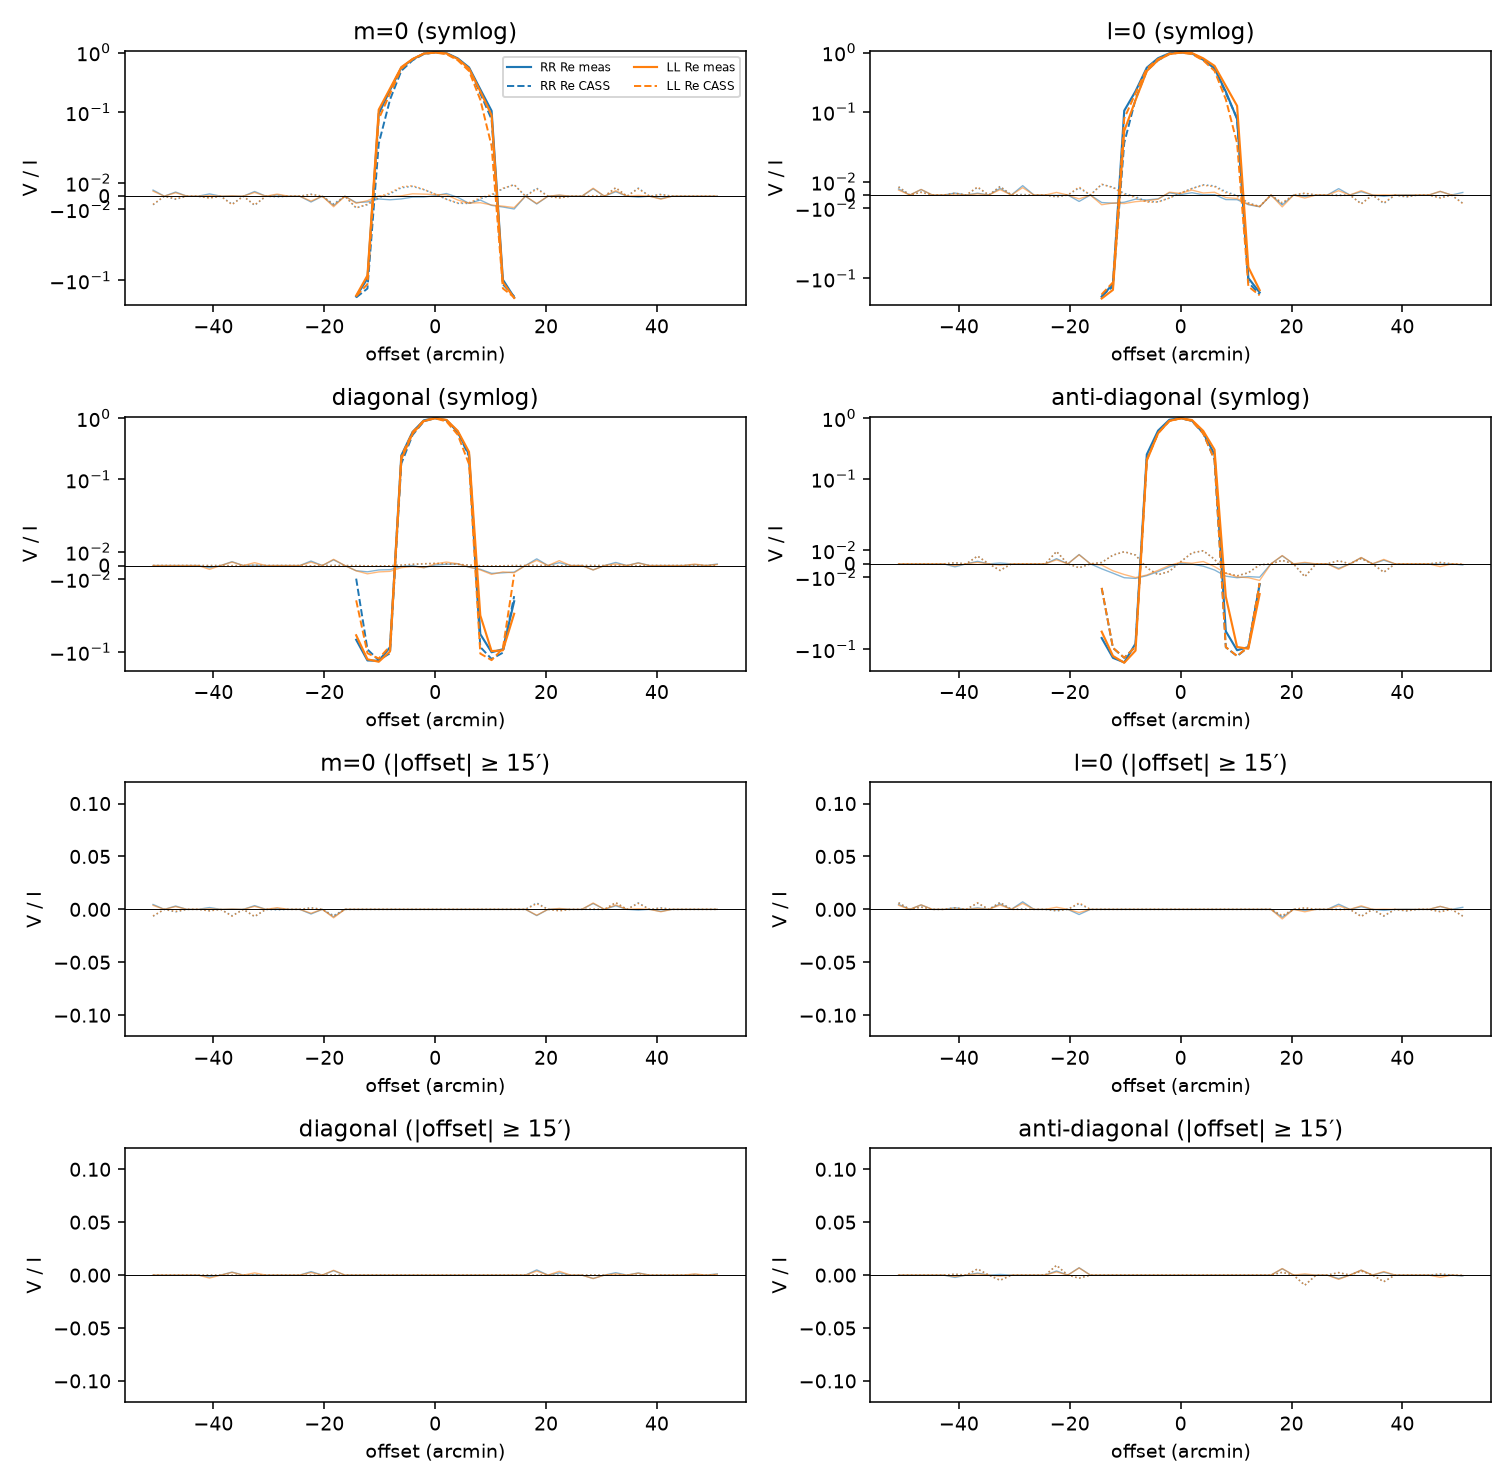

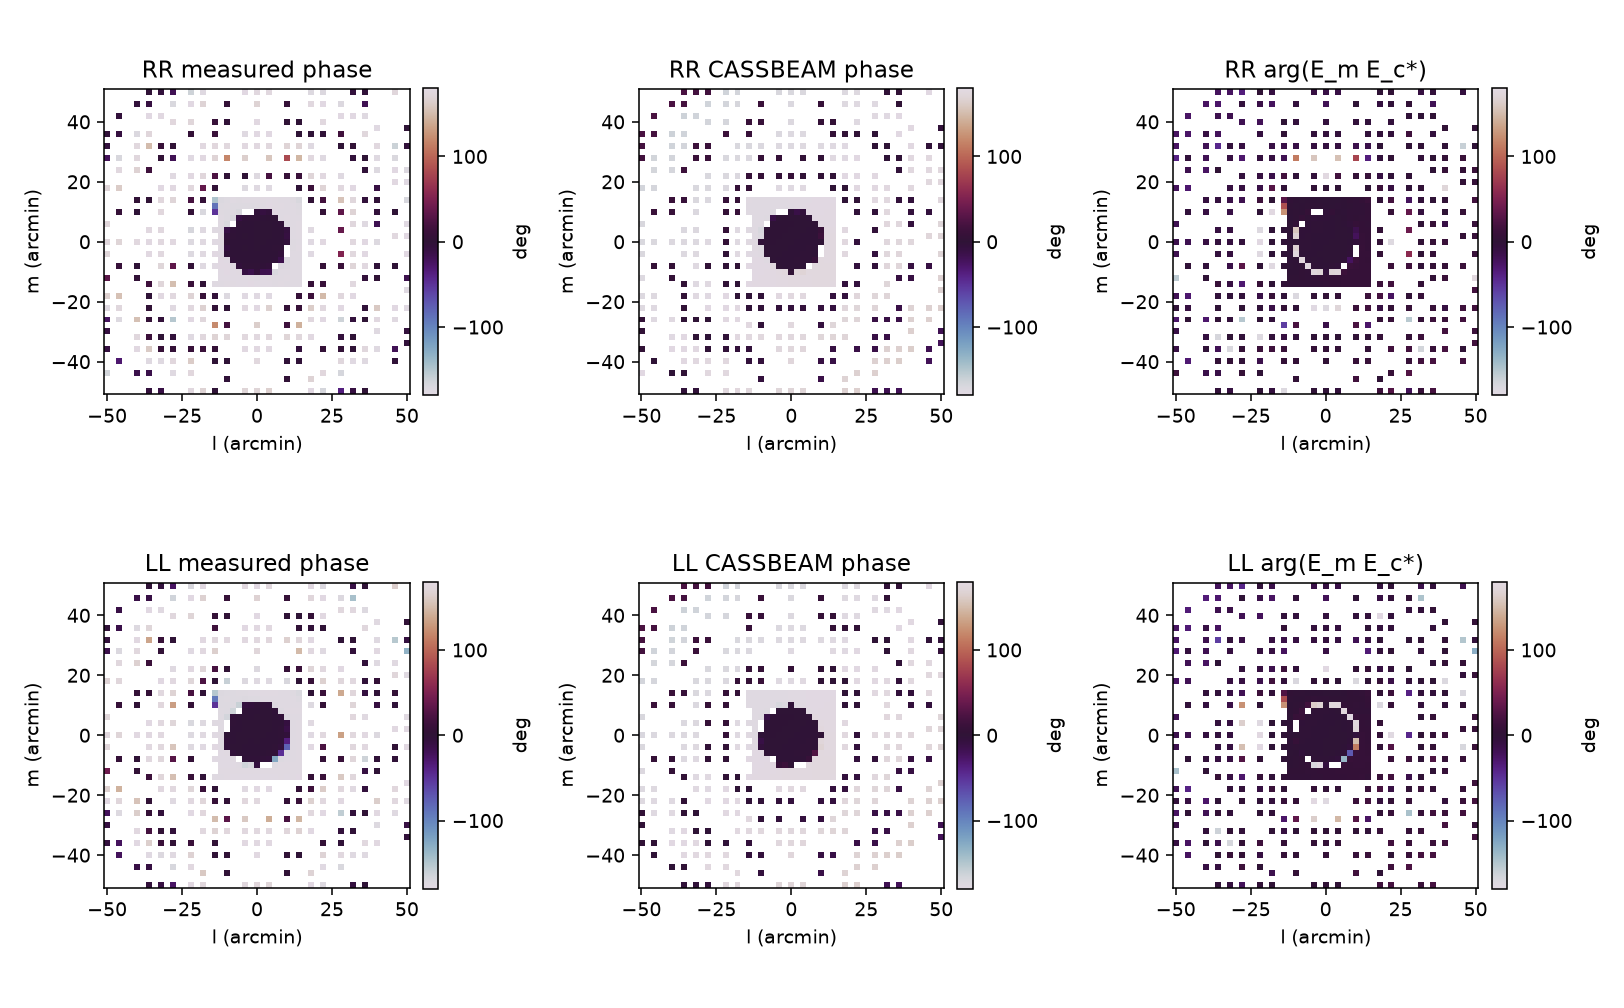

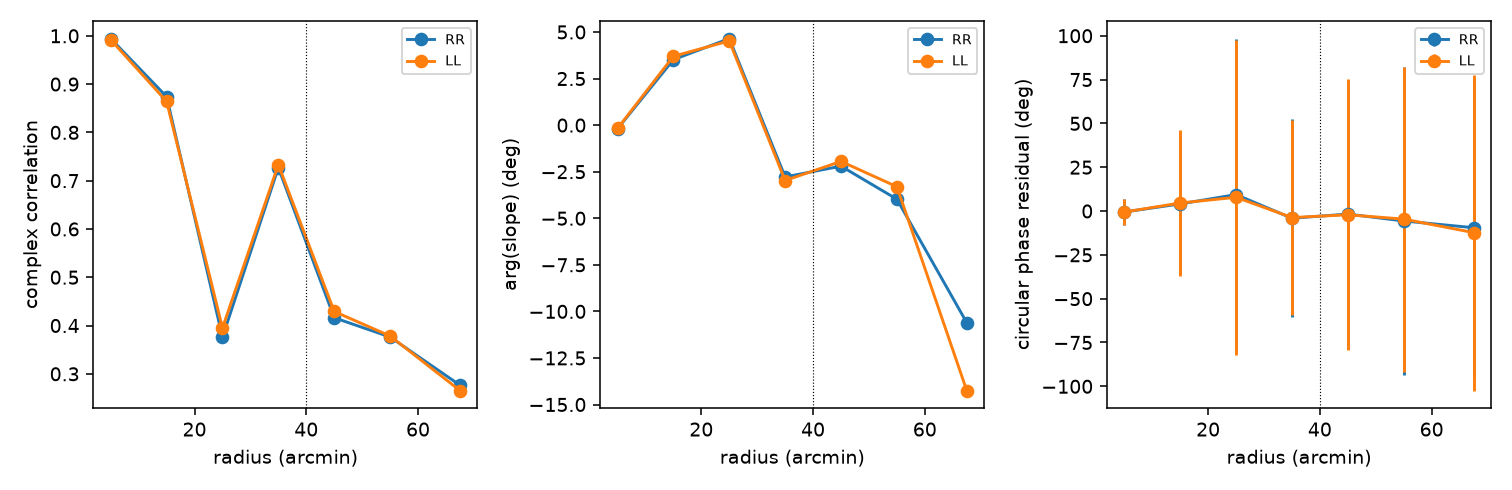

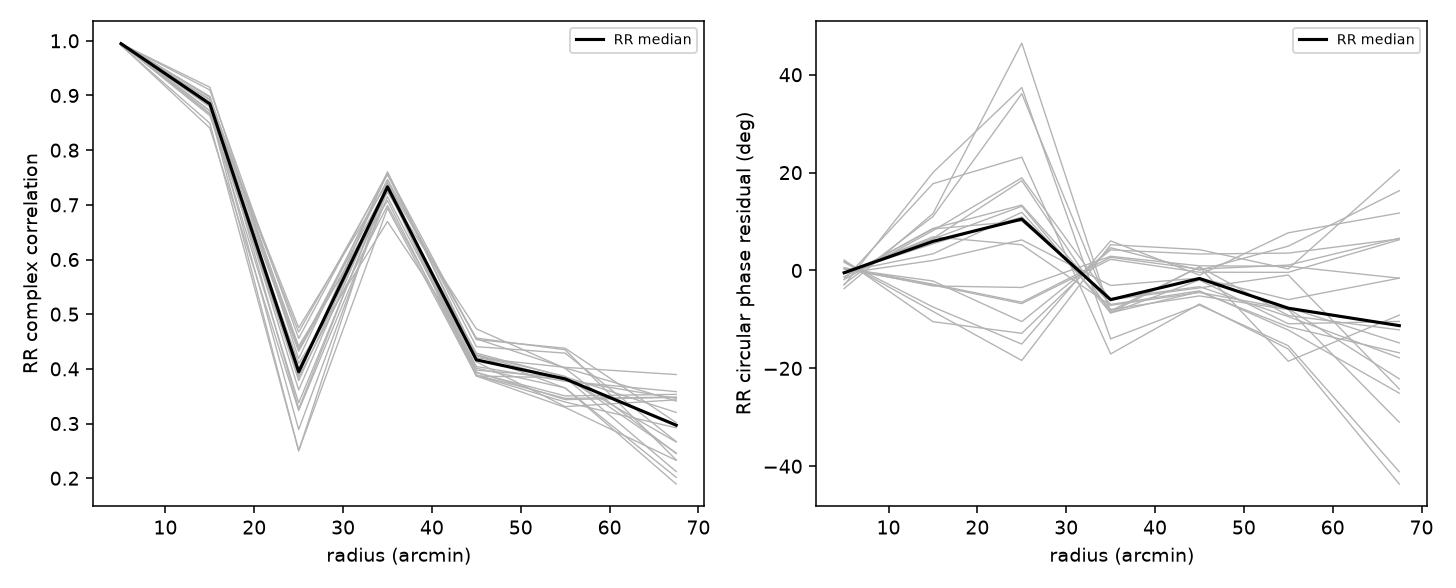

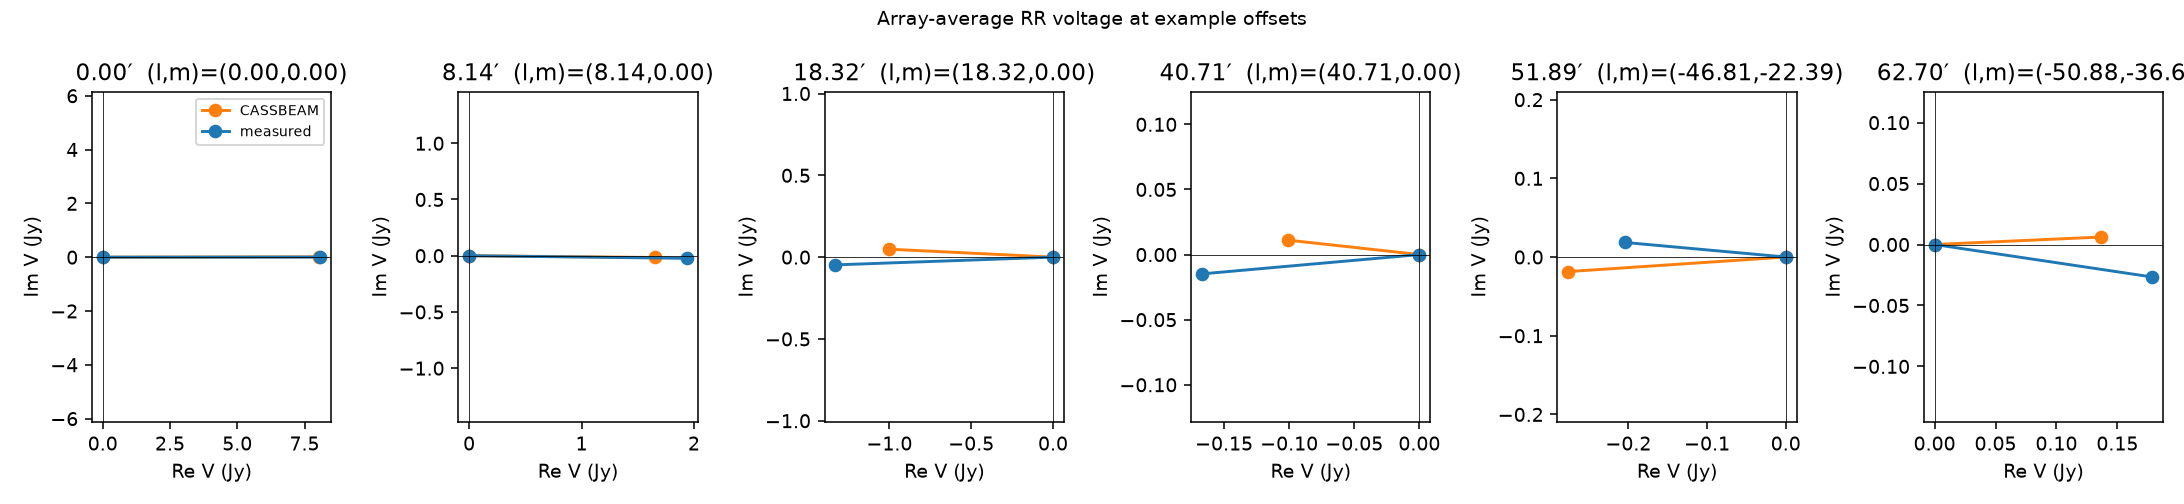

phase_status exploratory amp_floor_jy 0.05
extent {'l_abs_max': 50.60659700195147, 'm_abs_max': 51.90152170783606, 'corner_max': 72.48996906956783}
map phase >40' {'rr': {'n': 187.0, 'slope_real': 1.0285616735325214, 'slope_imag': -0.04236410637664613, 'correlation_abs': 0.8735443218230642, 'residual_power': 0.23880004392777449, 'median_abs_obs': 0.1645717731986221, 'median_abs_pred': 0.1390656506049397, 'median_abs_ratio': 1.1834106587984166, 'median_phase_deg': -1.468904505760378, 'circular_phase_deg': -3.553021946521799, 'circular_phase_std_deg': 27.801525685048553}, 'll': {'n': 181.0, 'slope_real': 1.0101679803065724, 'slope_imag': -0.04533400288375849, 'correlation_abs': 0.8652319293625077, 'residual_power': 0.25295411247951616, 'median_abs_obs': 0.16154212572346566, 'median_abs_pred': 0.14160133523487936, 'median_abs_ratio': 1.1408234636736283, 'median_phase_deg': -3.6319051743605093, 'circular_phase_deg': -5.161136290473407, 'circular_phase_std_deg': 30.42544743469816}}
rr [(5.0

In [10]:
show(
    "20_amplitude_db.png",
    "21_signed_complex_cuts.png",
    "22_masked_phase.png",
    "23_radial_coherence.png",
    "24_antenna_coherence.png",
    "25_bright_source_examples.png",
)
coh = bundle.radial_coherence
print("phase_status", coh.get("phase_status"), "amp_floor_jy", coh.get("amp_floor_jy"))
print("extent", coh.get("raster_extent_arcmin"))
print("map phase >40'", coh.get("map_phase_beyond_40_arcmin"))
for hand in ("rr", "ll"):
    print(hand, [(row["r_mid_arcmin"], row["correlation_abs"], row["circular_phase_deg"]) for row in coh.get(hand) or ()])
print("movers", [row["name"] for row in bundle.antenna_coherence.get("movers") or ()])
print("examples", [row.get("label") for row in bundle.bright_source_examples.get("examples") or ()])


## 9. R/L squint

The publication estimator is the 20%-of-peak main-lobe power centroid, with independent RR and LL flags and weights. The full-raster centroid is a bias diagnostic only.

measured sep 0.5152630312039774 memo 0.525854513584575 full_raster 0.3881490154611618 n 45539 44504
cassbeam sep 0.4114956291199375 memo 0.525854513584575 full_raster 0.4114950079073912 n 45500 45500


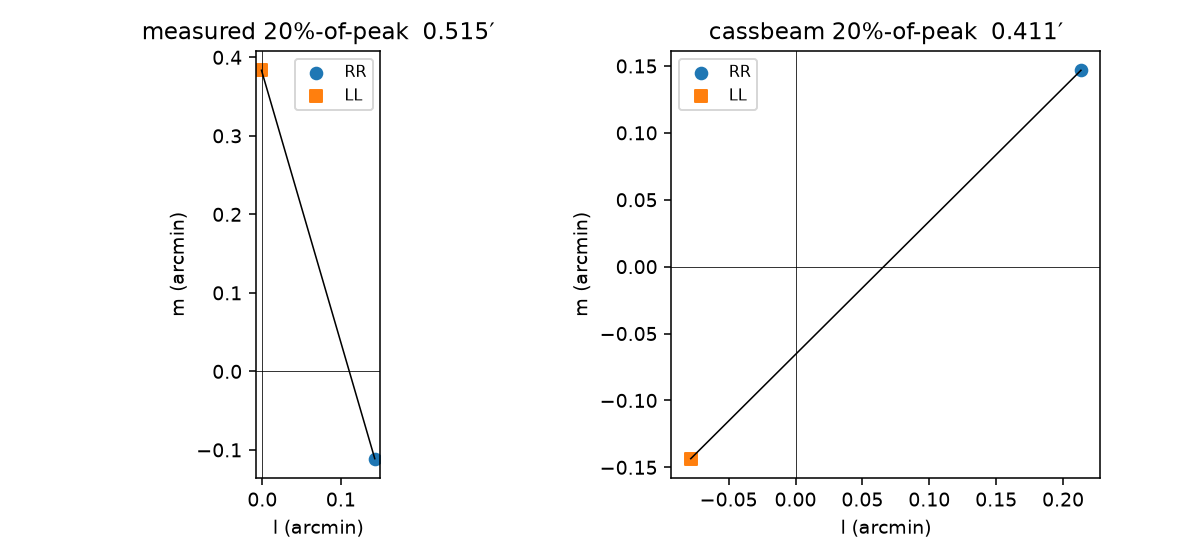

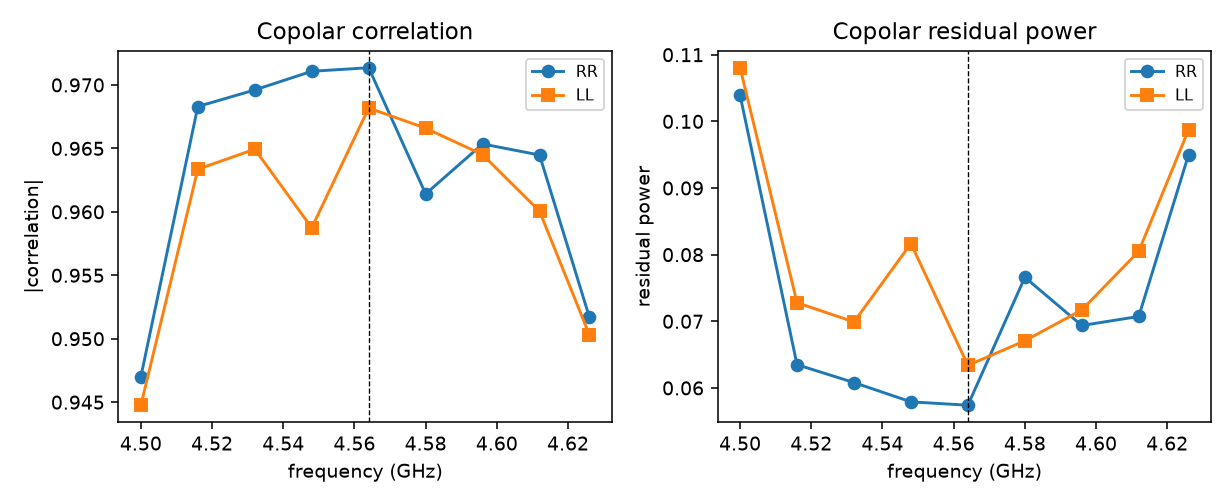

In [11]:
squint = publication_squint_pair(bundle.squint)
for name, row in squint.items():
    print(name, "sep", row["separation_arcmin"], "memo", row.get("memo195_separation_arcmin"),
          "full_raster", row["full_raster_separation_arcmin"], "n", row.get("n_rr"), row.get("n_ll"))
show("13_squint_mainlobe_20pct.png", "16_spw4_frequency.png")


## 10. C147-* offset ring

Fields 1–8 were unused prediction data. Offsets come from `FIELD.PHASE_DIR`. The CASA fringe $\exp(+2\pi i[ul+vm+w(n-1)])$ is required. The already-written ring Q/U used all 64 channels and is not a frequency holdout.

{'rr': 0.011685097778069658, 'll': 0.00900312429954719, 'passed': True, 'n_rr': 61776, 'n_ll': 61776, 'radius_arcmin': 3.6134405474883557, 'q_u_is_frequency_holdout': False}
inner/sealed scores {'inner_unit': {'fraction_positive': 0.995, 'improves': 1, 'power_full': 933458677663.1846, 'power_diag': 933815011920.1879}, 'inner_hat': {'fraction_positive': 1.0, 'improves': 1, 'power_full': 933556219191.4346, 'power_diag': 933815011920.1879}, 'sealed_unit': {'fraction_positive': 0.0, 'improves': 0, 'power_full': 842371592143.2294, 'power_diag': 842085659063.4562}, 'sealed_hat': {'fraction_positive': 0.0, 'improves': 0, 'power_full': 842225371954.194, 'power_diag': 842085659063.4562}, 'rrll_unit': {'fraction_positive': 0.2175, 'improves': 0, 'power_full': 6008293080085.199, 'power_diag': 6008268292509.19}}
Q/U is frequency holdout False


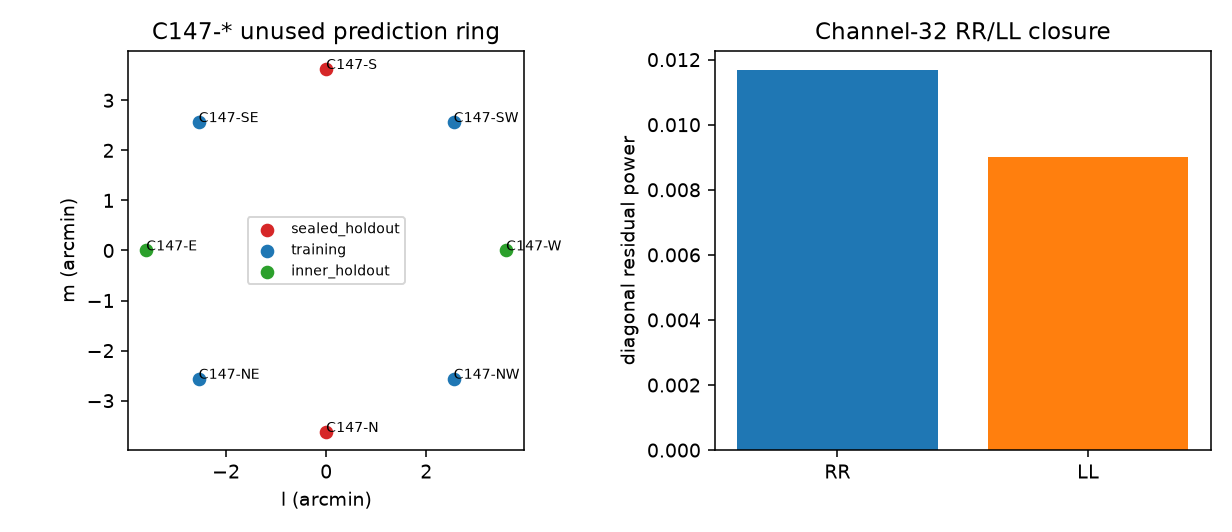

In [12]:
ring = offset_ring_diagonal_closure(bundle.offset_ring)
print(ring)
print("inner/sealed scores", bundle.offset_ring["scores"])
print("Q/U is frequency holdout", ring["q_u_is_frequency_holdout"])
show("17_c147_offset_ring.png")


## 11. Frequency transfer

This section is `not_run`. SPW 5 at 4.692 GHz remains sealed.

SPW 5 section status: not_run


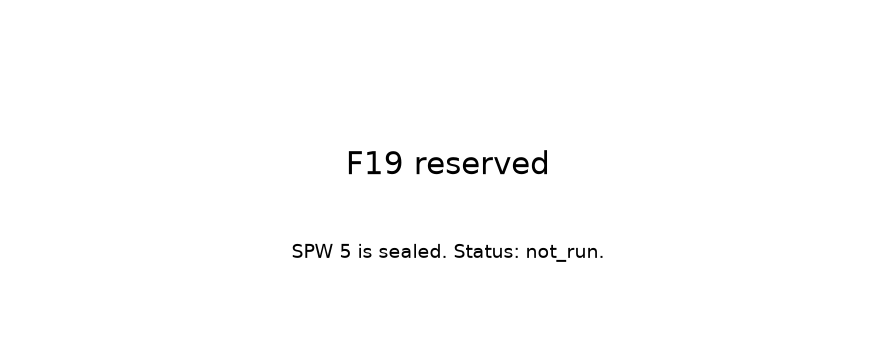

In [13]:
print("SPW 5 section status: not_run")
show("19_spw5_sealed.png")


## 12. Experimental full Jones

The locked mount-frame CASSBEAM full-Jones prediction is labelled experimental. The diagonal prediction is the null. A correlation near zero and residual power near one means the template explains almost none of the RL/LR variance. Because the observed cloud is larger than the predicted signal, this is a sensitivity-limited non-detection, not a clean rejection of CASSBEAM leakage physics.

{'rl_correlation': 0.10133092058292996, 'lr_correlation': 0.1035562336995104, 'rl_residual_power': 0.9936053081988492, 'lr_residual_power': 0.9921176253271361, 'rl_median_abs_obs': 0.1983866994632881, 'lr_median_abs_obs': 0.19822431005356644, 'rl_median_abs_pred': 0.005971810456799126, 'lr_median_abs_pred': 0.0057694304298438305}
predicted RL median 0.005971810456799126 observed 0.1983866994632881


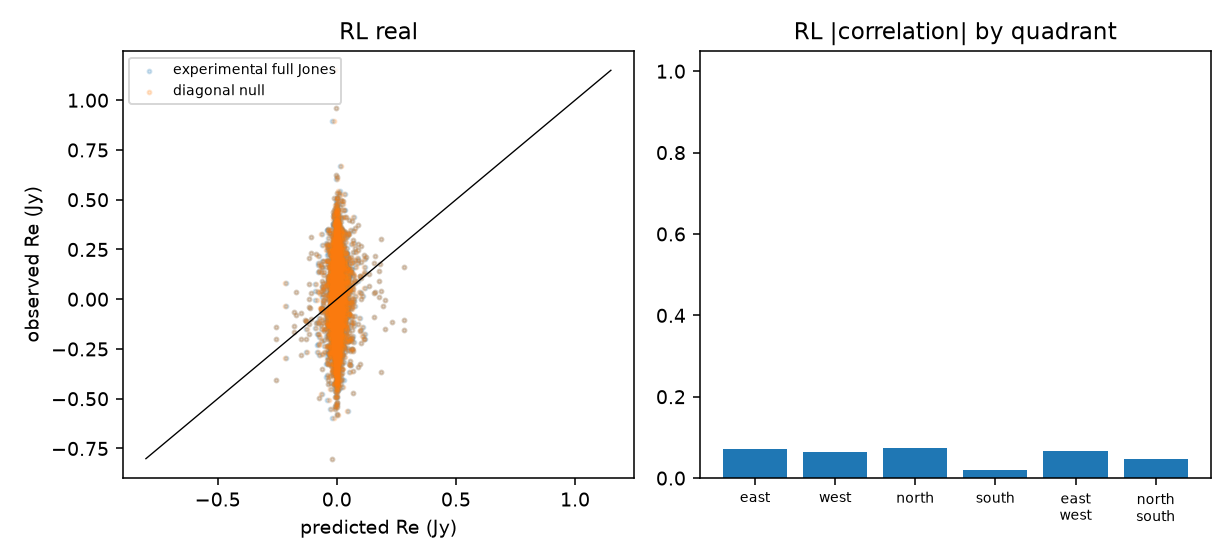

In [14]:
cross = crosshand_non_detection(bundle.holoraster_channel32)
print(cross)
print("predicted RL median", cross["rl_median_abs_pred"], "observed", cross["rl_median_abs_obs"])
show("18_experimental_crosshand.png")


## 13. Conclusions and limitations

Use CASSBEAM as the diagonal structural prior. Trust the main beam most strongly. Treat the mid beam as qualified. Attach substantial model uncertainty outside it. Keep explicit bright out-of-field source terms, because CASSBEAM alone can misestimate their apparent flux by factors of roughly two or more at particular outer locations. Do not infer a general outer phase correction from the current phase means.

The next scientific work is a validation-selected low-order diagonal correction. Outer-field corrections should be admitted only if they transfer across movers and spatial holdouts; otherwise bright outer sources should get source-specific nuisance terms or peeling rather than a globally corrected beam. Full Jones remains an experimental non-detection. SPW 5 remains sealed.

In [15]:
print("next artifact: cassbeam_diagonal_low_order_correction")
print("convention search reopened", bundle.convention_gates.get("cassbeam_convention", {}).get("note"))
for row in claim_table(bundle):
    print(row["id"], row["status"], row["evidence"])


next artifact: cassbeam_diagonal_low_order_correction
convention search reopened Locked mount-frame native packing. The 128-convention search is not reopened.
C01 pass HOLORASTER channel-32 residual power RR 0.64%, LL 0.76% (RMS visibility 7.97% / 8.72%; median |ΔV|/I 4.83% / 5.04%)
C02 warn HOLORASTER mid-beam residual power RR 7.70%, LL 8.91%
C03 warn HOLORASTER outer residual power RR 32.31%, LL 34.85%; complex correlation 0.825 / 0.812; median |V| ratio 1.61 / 1.60. Outer phase is exploratory and is not a claim metric.
C04 pass 3.61′ ring RR/LL residual power 1.17% / 0.90% after the geometric fringe
C05 blocked RL/LR correlation 0.101 / 0.104; residual power 0.994 / 0.992; predicted signal below the observed cloud
C06 not_run Reserved for one diagonal frequency-transfer test after a frozen SPW-4 correction
C07 pass Channel 32 measured 0.515′, Memo 195 0.526′, CASSBEAM 0.411′. The superseded full-raster measured centroid is retained only as a bias diagnostic
